In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_excel('10features_for_ML.xlsx',sheet_name='sheet1')

In [3]:
data.head()

,structures,Equation,reactants,products,reactionEnergy,Unnamed: 0,Structure,φ,Nd1,Np0,Out_e0,Out_e1,ψ1,First_IE0,CN,L_bond,R0,ΔGH
0,0,0.5H2(g) + * -> H*,"{""star"": 1, ""H2gas"": 0.5}","{""Hstar"": 1}",-0.107914,0,0,5.625000,8.419824,6.0,5.0,4.129565,1.903992,6.88,5.800000,1.812854,1.64,-0.107914
1,1,0.5H2(g) + * -> H*,"{""star"": 1, ""H2gas"": 0.5}","{""Hstar"": 1}",-0.230309,2218,1,21.491228,7.453910,6.0,9.0,9.463026,2.178410,7.46,7.500000,1.838814,1.42,-0.230309
2,2,0.5H2(g) + * -> H*,"{""star"": 1, ""H2gas"": 0.5}","{""Hstar"": 1}",-1.062136,3329,2,3.076923,3.301089,6.0,4.0,5.532647,1.604483,6.65,6.954545,2.127015,1.75,-1.062136
3,3,0.5H2(g) + * -> H*,"{""star"": 1, ""H2gas"": 0.5}","{""Hstar"": 1}",-0.195509,4437,3,25.654450,7.237624,6.0,9.0,9.240211,1.996451,7.16,7.500000,1.758147,1.26,-0.195509
4,4,0.5H2(g) + * -> H*,"{""star"": 1, ""H2gas"": 0.5}","{""Hstar"": 1}",0.364711,5539,4,3.076923,0.000000,6.0,4.0,3.000000,1.610000,6.65,7.500000,1.880105,1.75,0.364711


<AxesSubplot:>

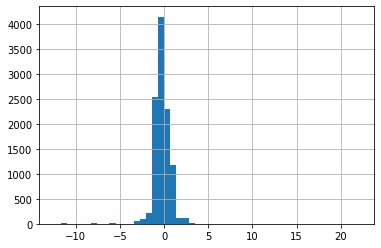

In [4]:
data['ΔGH'].hist(bins=50)
# plt.tight_layout()

In [5]:
# 将直方图数据导出为CSV文件
num_bins = 50  # 根据需要调整
hist_data, bin_edges = np.histogram(data['ΔGH'], bins=num_bins)

In [6]:
import csv
# 创建CSV文件并写入数据
with open('hist_data.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
#     print(writer)
    writer.writerow(['Bin_Edges', 'Frequency'])
    for edge, freq in zip(bin_edges, hist_data):
        writer.writerow([edge, freq])

In [7]:
data.describe() # 查看数据基本信息

,structures,reactionEnergy,Unnamed: 0,Structure,φ,Nd1,Np0,Out_e0,Out_e1,ψ1,First_IE0,CN,L_bond,R0,ΔGH
count,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000
mean,5498.324551,-0.247871,5508.751727,5498.324551,17.338871,4.593136,5.254988,6.706671,6.489067,2.103172,8.309671,5.474580,1.795336,1.392558,-0.247871
std,3209.316540,1.045836,3185.233110,3209.316540,17.127992,3.502478,1.503070,2.543282,2.443863,0.536339,2.249322,2.416623,0.326048,0.290549,1.045836
min,0.000000,-12.396552,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.000000,0.943398,5.577000,0.250000,0.965532,0.660000,-12.396552
25%,2716.500000,-0.731606,2758.500000,2716.500000,3.076923,1.000000,6.000000,5.000000,5.000000,1.724626,6.989846,3.000000,1.691852,1.320000,-0.731606
50%,5447.000000,-0.284465,5477.000000,5447.000000,13.157895,4.760938,6.000000,6.000000,5.732657,1.953389,7.726000,6.954545,1.835832,1.421591,-0.284465
75%,8286.500000,0.279476,8291.500000,8286.500000,28.070175,7.770060,6.000000,9.000000,8.387179,2.313534,8.556565,7.500000,1.961393,1.540000,0.279476
max,11107.000000,22.060583,11067.000000,11107.000000,61.728395,10.000000,6.000000,12.000000,12.000000,3.440000,14.534000,11.375000,4.049090,2.070000,22.060583


In [8]:
data = data.iloc[:,7:]
data

,φ,Nd1,Np0,Out_e0,Out_e1,ψ1,First_IE0,CN,L_bond,R0,ΔGH
0,5.625000,8.419824,6.0,5.0,4.129565,1.903992,6.880,5.800000,1.812854,1.64,-0.107914
1,21.491228,7.453910,6.0,9.0,9.463026,2.178410,7.460,7.500000,1.838814,1.42,-0.230309
2,3.076923,3.301089,6.0,4.0,5.532647,1.604483,6.650,6.954545,2.127015,1.75,-1.062136
3,25.654450,7.237624,6.0,9.0,9.240211,1.996451,7.160,7.500000,1.758147,1.26,-0.195509
4,3.076923,0.000000,6.0,4.0,3.000000,1.610000,6.650,7.500000,1.880105,1.75,0.364711
...,...,...,...,...,...,...,...,...,...,...,...
10850,16.363636,0.000000,6.0,8.0,5.000000,3.040000,7.370,3.250000,1.606843,1.46,0.834068
10851,0.000000,6.000000,3.0,5.0,8.000000,2.200000,14.534,3.000000,1.030496,0.71,-0.655943
10852,2.597403,0.000000,6.0,4.0,5.000000,3.040000,6.820,4.125000,2.079733,1.60,-0.925217
10853,3.007519,0.000000,6.0,4.0,5.000000,3.040000,6.840,4.285714,2.176556,1.75,-1.013876


In [9]:
data.duplicated().sum()  # 若果是0表述没有重复数据

96

In [10]:
df_unique = data.drop_duplicates()

In [11]:
df_unique_index = df_unique.index

In [12]:
print(df_unique)

               φ       Nd1  Np0  Out_e0    Out_e1        ψ1  First_IE0  \
0       5.625000  8.419824  6.0     5.0  4.129565  1.903992      6.880   
1      21.491228  7.453910  6.0     9.0  9.463026  2.178410      7.460   
2       3.076923  3.301089  6.0     4.0  5.532647  1.604483      6.650   
3      25.654450  7.237624  6.0     9.0  9.240211  1.996451      7.160   
4       3.076923  0.000000  6.0     4.0  3.000000  1.610000      6.650   
...          ...       ...  ...     ...       ...       ...        ...   
10850  16.363636  0.000000  6.0     8.0  5.000000  3.040000      7.370   
10851   0.000000  6.000000  3.0     5.0  8.000000  2.200000     14.534   
10852   2.597403  0.000000  6.0     4.0  5.000000  3.040000      6.820   
10853   3.007519  0.000000  6.0     4.0  5.000000  3.040000      6.840   
10854  16.363636  0.000000  6.0     8.0  5.000000  3.040000      7.370   

             CN    L_bond    R0       ΔGH  
0      5.800000  1.812854  1.64 -0.107914  
1      7.500000  1.8388

In [13]:
print(df_unique_index)

Int64Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,
                9,
            ...
            10845, 10846, 10847, 10848, 10849, 10850, 10851, 10852, 10853,
            10854],
           dtype='int64', length=10759)


In [14]:
df_unique_index1 = 'chongfu.txt'
 
with open(df_unique_index1, 'w') as file:
    for item in df_unique_index:
        file.write(str(item) + '\n')

In [15]:
data = data.drop_duplicates()
data

,φ,Nd1,Np0,Out_e0,Out_e1,ψ1,First_IE0,CN,L_bond,R0,ΔGH
0,5.625000,8.419824,6.0,5.0,4.129565,1.903992,6.880,5.800000,1.812854,1.64,-0.107914
1,21.491228,7.453910,6.0,9.0,9.463026,2.178410,7.460,7.500000,1.838814,1.42,-0.230309
2,3.076923,3.301089,6.0,4.0,5.532647,1.604483,6.650,6.954545,2.127015,1.75,-1.062136
3,25.654450,7.237624,6.0,9.0,9.240211,1.996451,7.160,7.500000,1.758147,1.26,-0.195509
4,3.076923,0.000000,6.0,4.0,3.000000,1.610000,6.650,7.500000,1.880105,1.75,0.364711
...,...,...,...,...,...,...,...,...,...,...,...
10850,16.363636,0.000000,6.0,8.0,5.000000,3.040000,7.370,3.250000,1.606843,1.46,0.834068
10851,0.000000,6.000000,3.0,5.0,8.000000,2.200000,14.534,3.000000,1.030496,0.71,-0.655943
10852,2.597403,0.000000,6.0,4.0,5.000000,3.040000,6.820,4.125000,2.079733,1.60,-0.925217
10853,3.007519,0.000000,6.0,4.0,5.000000,3.040000,6.840,4.285714,2.176556,1.75,-1.013876


In [16]:
data = data[(data['ΔGH'] > -2) &  (data['ΔGH'] < 2) ]
data

,φ,Nd1,Np0,Out_e0,Out_e1,ψ1,First_IE0,CN,L_bond,R0,ΔGH
0,5.625000,8.419824,6.0,5.0,4.129565,1.903992,6.880,5.800000,1.812854,1.64,-0.107914
1,21.491228,7.453910,6.0,9.0,9.463026,2.178410,7.460,7.500000,1.838814,1.42,-0.230309
2,3.076923,3.301089,6.0,4.0,5.532647,1.604483,6.650,6.954545,2.127015,1.75,-1.062136
3,25.654450,7.237624,6.0,9.0,9.240211,1.996451,7.160,7.500000,1.758147,1.26,-0.195509
4,3.076923,0.000000,6.0,4.0,3.000000,1.610000,6.650,7.500000,1.880105,1.75,0.364711
...,...,...,...,...,...,...,...,...,...,...,...
10850,16.363636,0.000000,6.0,8.0,5.000000,3.040000,7.370,3.250000,1.606843,1.46,0.834068
10851,0.000000,6.000000,3.0,5.0,8.000000,2.200000,14.534,3.000000,1.030496,0.71,-0.655943
10852,2.597403,0.000000,6.0,4.0,5.000000,3.040000,6.820,4.125000,2.079733,1.60,-0.925217
10853,3.007519,0.000000,6.0,4.0,5.000000,3.040000,6.840,4.285714,2.176556,1.75,-1.013876


In [17]:
data = data.dropna() # 删除缺失值 

In [18]:
# data = data.drop(labels=corrrlation_features,axis=1)
data

,φ,Nd1,Np0,Out_e0,Out_e1,ψ1,First_IE0,CN,L_bond,R0,ΔGH
0,5.625000,8.419824,6.0,5.0,4.129565,1.903992,6.880,5.800000,1.812854,1.64,-0.107914
1,21.491228,7.453910,6.0,9.0,9.463026,2.178410,7.460,7.500000,1.838814,1.42,-0.230309
2,3.076923,3.301089,6.0,4.0,5.532647,1.604483,6.650,6.954545,2.127015,1.75,-1.062136
3,25.654450,7.237624,6.0,9.0,9.240211,1.996451,7.160,7.500000,1.758147,1.26,-0.195509
4,3.076923,0.000000,6.0,4.0,3.000000,1.610000,6.650,7.500000,1.880105,1.75,0.364711
...,...,...,...,...,...,...,...,...,...,...,...
10850,16.363636,0.000000,6.0,8.0,5.000000,3.040000,7.370,3.250000,1.606843,1.46,0.834068
10851,0.000000,6.000000,3.0,5.0,8.000000,2.200000,14.534,3.000000,1.030496,0.71,-0.655943
10852,2.597403,0.000000,6.0,4.0,5.000000,3.040000,6.820,4.125000,2.079733,1.60,-0.925217
10853,3.007519,0.000000,6.0,4.0,5.000000,3.040000,6.840,4.285714,2.176556,1.75,-1.013876


In [19]:
data.info()# 查看数据基本信息

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10377 entries, 0 to 10854
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   φ          10377 non-null  float64
 1   Nd1        10377 non-null  float64
 2   Np0        10377 non-null  float64
 3   Out_e0     10377 non-null  float64
 4   Out_e1     10377 non-null  float64
 5   ψ1         10377 non-null  float64
 6   First_IE0  10377 non-null  float64
 7   CN         10377 non-null  float64
 8   L_bond     10377 non-null  float64
 9   R0         10377 non-null  float64
 10  ΔGH        10377 non-null  float64
dtypes: float64(11)
memory usage: 972.8 KB


In [20]:
X_O = data.iloc[:,0:-1]
y_O = data['ΔGH']

<AxesSubplot:>

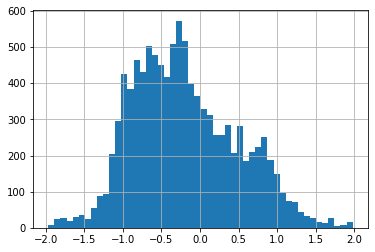

In [21]:
data['ΔGH'].hist(bins=50)
# plt.tight_layout()

In [22]:
from sklearn.neighbors import KNeighborsRegressor  # KNN
from sklearn.svm import SVR  # SVR
from sklearn.ensemble import RandomForestRegressor  #RF
from sklearn.neural_network import MLPRegressor   # NN
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error # , neg_root_mean_squared_error, neg_mean_absolute_error
from sklearn.model_selection import GridSearchCV, cross_val_score
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
font = FontProperties(fname=r"c:\windows\fonts\msyh.ttc", size = 20)
from xgboost import XGBRegressor as XGBR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import KFold, cross_val_score as CVS, train_test_split as TTS
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import KFold, cross_val_score
import time
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor

In [23]:
X_O = data.iloc[:,0:-1]
y_O = data['ΔGH']

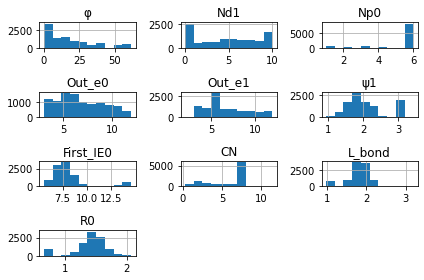

In [24]:
X_O.hist()
plt.tight_layout()

# ETR model

In [25]:
def etr():

    x_train,x_test,y_train,y_test = train_test_split(X_O,y_O,test_size=0.2,random_state=68)

    etr = ExtraTreesRegressor()


    parameters= {
    #     'min_samples_leaf':list(range(6,10,2)),
        'n_estimators':list(range(50,51,1))
        ,'max_depth':list(range(25,36,1))
    }

    grid = GridSearchCV(estimator=ExtraTreesRegressor(random_state=178) ,param_grid=parameters,n_jobs= -1,cv=10)
    etr_model = grid.fit(x_train,y_train)
    best_parameters = grid.best_params_
    print(best_parameters)


    y_etr_pre_train = etr_model.predict(x_train)
    y_etr_pred = etr_model.predict(x_test)


    mae_train = mean_absolute_error(y_etr_pre_train,y_train)
    mse_train = mean_squared_error(y_etr_pre_train,y_train)
    R2_train = r2_score(y_train,y_etr_pre_train)
    print('training R2 = {:.3f} V'.format(R2_train))
    print('training mae = {:.3f} V'.format(mae_train))
    print('training mse = {:.3f} V'.format(mse_train))
    print('training RMSE = {:.3f} V'.format(np.sqrt(mse_train)))

    print()

    mae_test = mean_absolute_error(y_etr_pred,y_test)
    mse_test = mean_squared_error(y_etr_pred,y_test)
    R2_test = r2_score(y_test,y_etr_pred)
    print('test R2 = {:.3f} V'.format(R2_test))
    print('test mae = {:.3f} V'.format(mae_test))
    print('test mse = {:.3f} V'.format(mse_test))
    print('test RMSE = {:.3f} V'.format(np.sqrt(mse_test)))

In [26]:
etr()

{'max_depth': 26, 'n_estimators': 50}
training R2 = 0.999 V
training mae = 0.004 V
training mse = 0.000 V
training RMSE = 0.019 V

test R2 = 0.922 V
test mae = 0.093 V
test mse = 0.034 V
test RMSE = 0.186 V


预测吸附能：
 [ 0.45975789  0.43551032  0.06838686 ...  0.69318567  0.49745425
 -0.27404647]
真实吸附能：
 6875    0.456488
7641    0.430446
607     0.181478
8255    0.063126
6504   -0.636116
          ...   
1459    0.626631
7284    0.084810
4574    0.661356
7242    0.497440
9897   -0.344120
Name: ΔGH, Length: 2076, dtype: float64
正规方程误差MSE为：
 0.03434763200386658
Score得分为：
 0.9222837261339274
feature_importances重要性为：
 [0.27739631 0.08802443 0.0815927  0.06847029 0.03347762 0.03408256
 0.04818458 0.08597447 0.22125826 0.06153878]


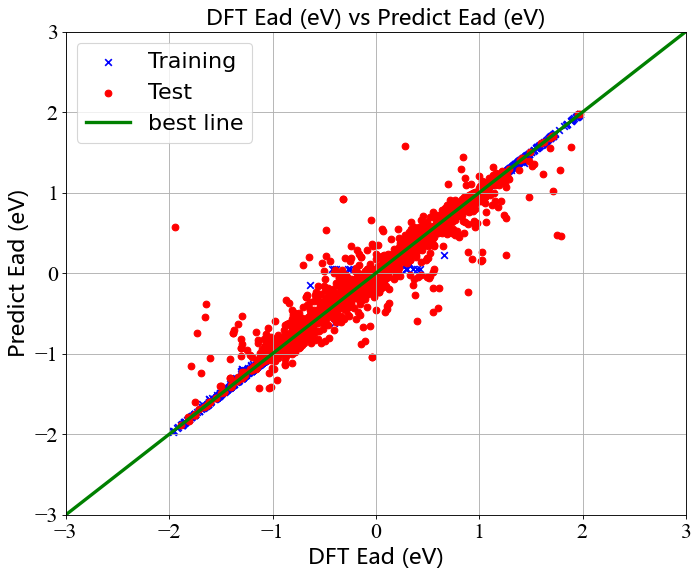

In [27]:
x_train,x_test,y_train,y_test = train_test_split(X_O,y_O,test_size=0.2,random_state=68)
# # 3、标准化
# transfer = StandardScaler()
# x_train = transfer.fit_transform(x_train)
# x_test = transfer.transform(x_test)

# 4、预估器
estimator = ExtraTreesRegressor(n_estimators=52,max_depth=26,random_state=178)

# 加入交叉验证
#     param_dict = {"n_neighbors": [1,3,5,7,9,11]}
#     estimator = GridSearchCV(estimator,param_grid = param_dict, cv = 5)
estimator.fit(x_train, y_train) 


# 5、得出模型
#     print("正规方程-权重系数为：\n", estimator.coef_)  # 回归系数
#     print("正规方程-偏置为：\n", estimator.intercept_) # 截距

# 6、模型评估
y_predict = estimator.predict(x_test)
print("预测吸附能：\n", y_predict)
print("真实吸附能：\n", y_test)
error = mean_squared_error(y_test, y_predict)
print("正规方程误差MSE为：\n", error)

#     error1 = neg_root_mean_squared_error(y_test, y_predict)
#     print("正规方程误差MSE为：\n", error1)

#     error2 = neg_mean_absolute_error(y_test, y_predict)
#     print("正规方程误差MSE为：\n", error2)

score = estimator.score(x_test, y_test)
print("Score得分为：\n", score)
feature_importances = estimator.fit(x_train,y_train).feature_importances_
print("feature_importances重要性为：\n", feature_importances)

y_train_predict = estimator.predict(x_train)

# print("交叉验证：",cross_val_score(estimator,x_Fast_O.iloc[:,2:-4],y_Fast_O,cv=10,scoring="neg_mean_squared_error")*(-1))

            
# 7、画图
import matplotlib.pyplot as plt
# 1、创建画布
plt.figure(figsize=(10, 8), dpi=80)
plt.title('DFT Ead (eV) vs Predict Ead (eV)',fontproperties=font)
plt.xlabel('DFT Ead (eV)',fontproperties=font)
plt.ylabel('Predict Ead (eV)',fontproperties=font)
plt.axis([-3, 3, -3, 3])
plt.xticks(fontproperties = 'Times New Roman', size = 20)
plt.yticks(fontproperties = 'Times New Roman', size = 20)
plt.grid(True)
X = y_test
y = y_predict


# 2、绘制图像
plt.scatter(y_train, y_train_predict,  color="blue", marker = 'x', label = 'Training')
plt.scatter(y_test, y_predict, color="red", label = 'Test')

plt.legend(loc=2,fontsize=20)  

# 3、绘制线性拟合曲线
#  拟合曲线应该是y_test 和 y_predict之前的线性拟合

# estimator1 = LinearRegression()
# y_train = y_train.values.reshape(-1,1)
# estimator1.fit(y_train, y_train_predict)
# print("真实值和预测值的回归系数：\n", estimator1.coef_)  # 回归系数
# print("真实值和预测值的截距：\n", estimator1.intercept_) # 截距
# y_train_predict = estimator1.predict(y_train)
#     plt.plot(y_train, y_train_predict, color='black', linewidth=3, label="best line")

# 线能不能延长一些

import numpy as np
# 1、准备x，y数据
x = np.linspace(-3, 3, 1000)
y =  x 
plt.plot(x, y, color='green', linewidth=3, label="best line")
plt.legend(loc=2,fontsize=20)  


In [28]:
estimator

ExtraTreesRegressor(max_depth=26, n_estimators=52, random_state=178)

In [29]:
import shap
shap_values = shap.TreeExplainer(estimator).shap_values(x_test)

In [30]:
data_with_name = pd.DataFrame(x_test)

In [31]:
data_with_name.columns = ['φ','Nd1','Np0','Out_e0','Out_e1','ψ1','First_IE0','CN','L_bond','R0']

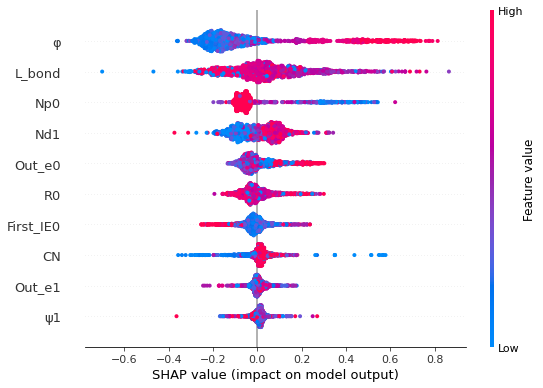

In [32]:
shap.summary_plot(shap_values,data_with_name,show=False)
plt.savefig('shap_feature_value_10_H.png')
plt.savefig('shap_feature_value_10_H.svg',format='svg')

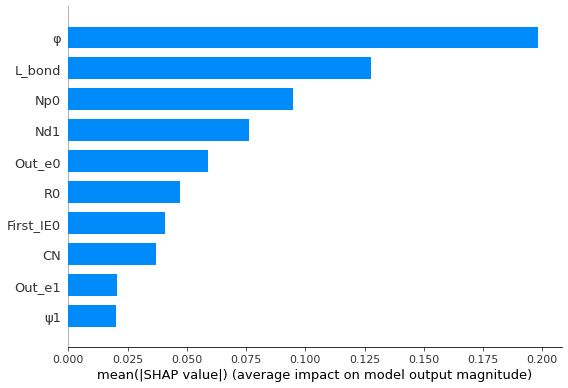

In [33]:
shap.summary_plot(shap_values,data_with_name,plot_type='bar',show=False,cmap='PiYG')
plt.savefig('features_importance_10_H')
plt.savefig('features_importance_10_H.svg',format='svg')

In [34]:
# 以SHAP的Explanation对象形式输出SHAP值
explainer = shap.TreeExplainer(estimator)
shap_values2 = explainer(x_test)

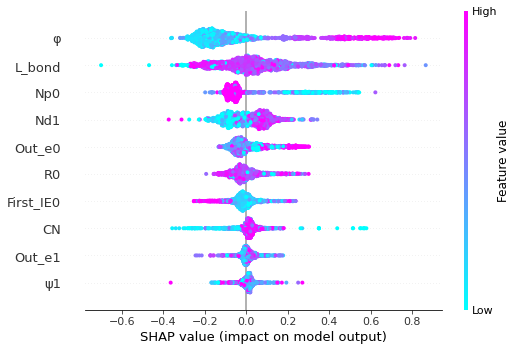

In [35]:
shap.plots.beeswarm(shap_values2, 
                    color=plt.get_cmap("cool"))

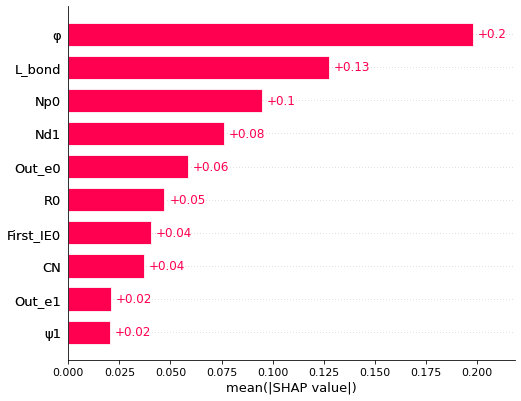

In [36]:
# 图形1：全局条形图summary_plot
# 方法二
shap.plots.bar(shap_values2,show=False)
plt.savefig('features10_importance_H.svg',format='svg')

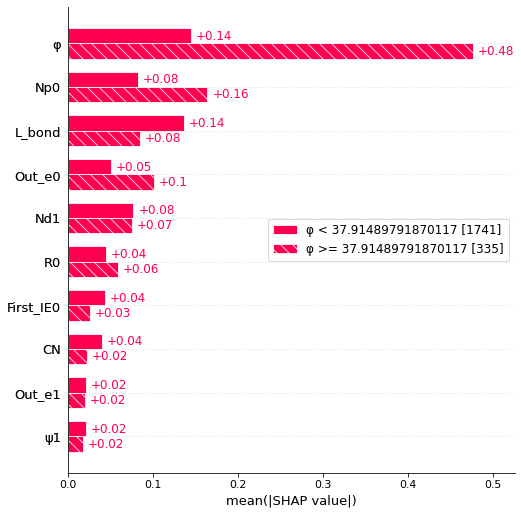

In [37]:
# 图形3：队列条形图（自动分组）
v = shap_values2.cohorts(2).abs.mean(0)
shap.plots.bar(v)

In [38]:
# 图11：interaction_values
shap_interaction_values = explainer.shap_interaction_values(x_test)

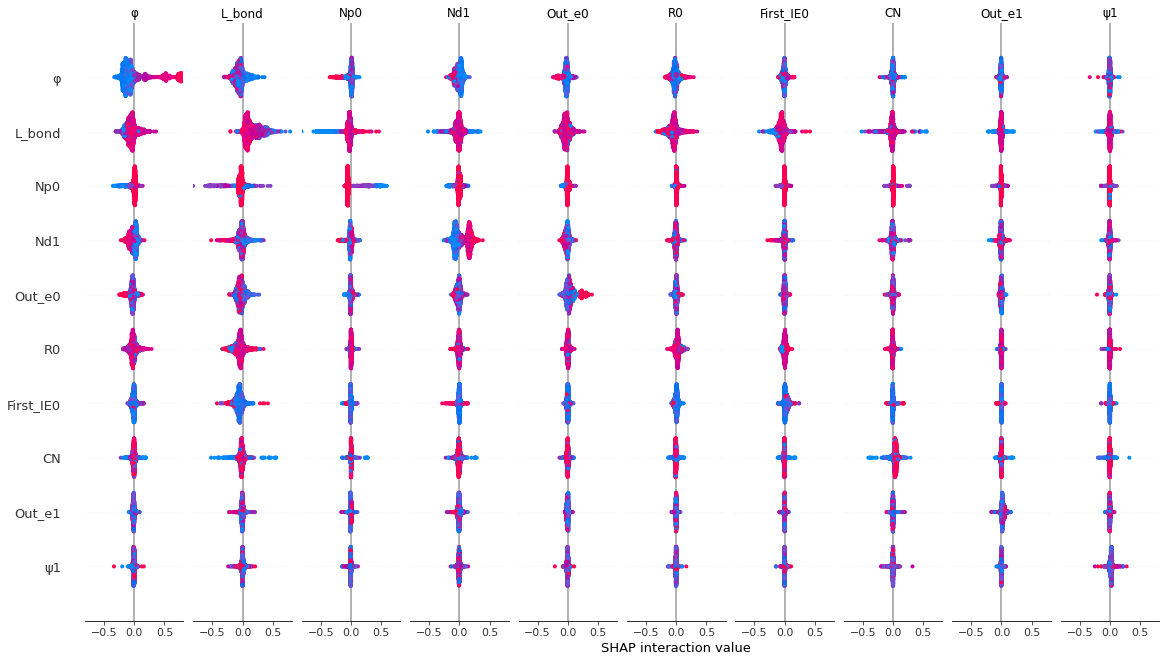

In [39]:
shap.summary_plot(shap_interaction_values, x_test,max_display=10,show=False)
plt.savefig('shap_feature10_interaction.svg',format='svg')

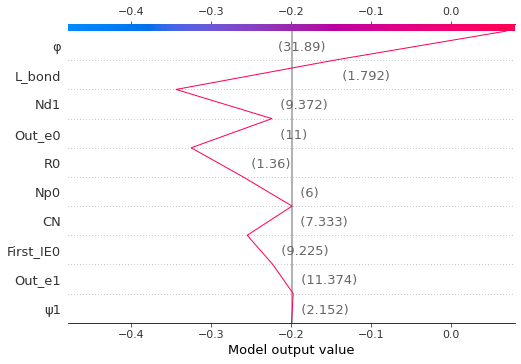

In [40]:
# 图12：Decision Plot
explainer = shap.TreeExplainer(estimator)
expected_value = explainer.expected_value
# 限制20个样本
features = x_test.iloc[range(20)]
# 展示第一条样本
shap_values = explainer.shap_values(features)[2]

shap.decision_plot(expected_value, shap_values, 
                   features)

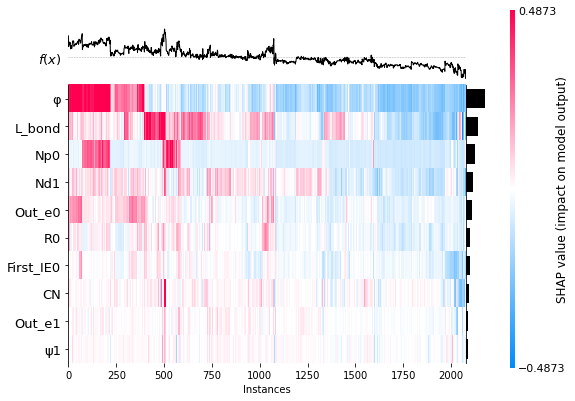

In [41]:
# 图13：热图
shap.plots.heatmap(shap_values2)

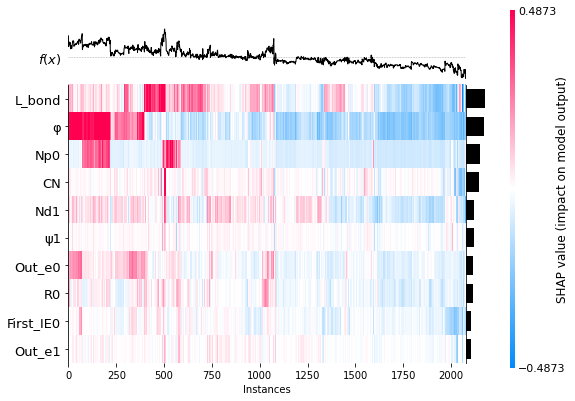

In [42]:
# 更改特征排序
shap.plots.heatmap(shap_values2, 
                   feature_values=shap_values2.abs.max(0))

In [43]:
shap_values2.sum(1)

.values =
array([ 0.65929639,  0.63504882,  0.26792536, ...,  0.89272417,
        0.69699275, -0.07450797])

.data =
array([ 91.49864211,  99.37879392,  83.00081395, ..., 114.63272297,
        36.466144  ,  84.83931644])

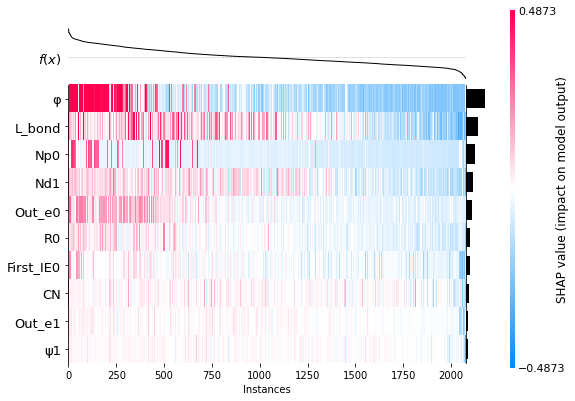

In [44]:
# 更改特征排序
shap.plots.heatmap(shap_values2, 
                   instance_order=shap_values2.sum(1))

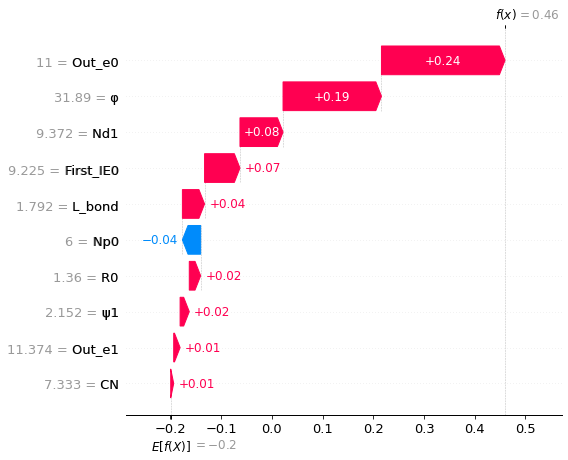

In [45]:
# 图14：瀑布图
shap.plots.waterfall(shap_values2[0],show=False)
plt.tight_layout()  # 自动调整布局，防止内容被遮挡
plt.savefig('CrOs_7723.svg',format='svg', bbox_inches='tight')

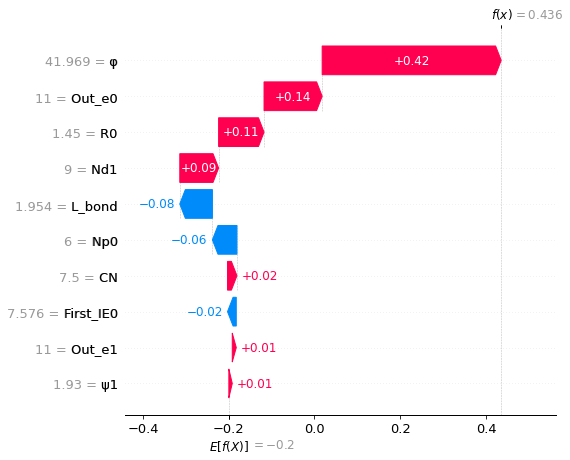

In [46]:
# 图14：瀑布图
shap.plots.waterfall(shap_values2[1],show=False)
plt.tight_layout()  # 自动调整布局，防止内容被遮挡
plt.savefig('Ru3Pb_8610.svg',format='svg', bbox_inches='tight')

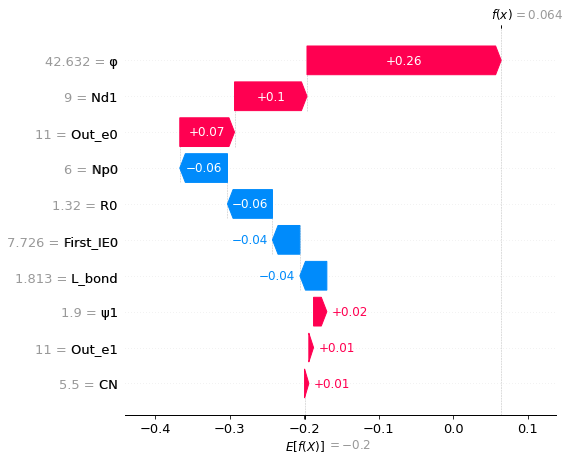

In [47]:
# 图14：瀑布图
shap.plots.waterfall(shap_values2[3],show=False)
plt.tight_layout()  # 自动调整布局，防止内容被遮挡
plt.savefig('ReN2_9295.svg',format='svg', bbox_inches='tight')

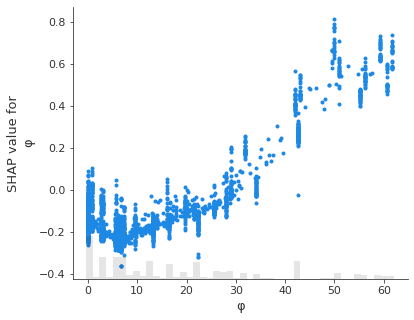

In [48]:
# 绘制散点图
shap.plots.scatter(shap_values2[:,"φ" ])